# Model
## 1. 核心功能
 本商品面向材料化学领域Al4S开发者打造，覆盖学术前沿探索与工业研发的高性能模拟场景。基于OneScience科学智能计算框架，本商品提供MACE、UMA等主流模型算法的适配与复现，同时集成了MPtrj、OC20、QM9等权威数据集。我们致力于构建从数据到模型的全链路工具支撑，助力开发者实现算法的敏捷开发与高效迭代。

## 2. 热点模型和数据信息
### 2.1 热点模型
| 模型名称 | 开发团队及简介 | OneScience功能支持 | 与传统软件的耦合 |
|:---:|:---:|:---:|:---:|
| **MACE** | 剑桥大学等团队，基于高阶等变性架构的新一代机器学习势函数，兼具极高精度与强泛化性能。 | 训练、微调、推理全流程开发 | 以插件形式集成于LAMMPS，支持在DCU平台下进行大规模分子动力学模拟 |
| **UMA** | Meta FAIR团队，针对大规模材料筛选设计的普适性预训练模型，侧重于超大规模体系的高效模拟。 | 微调、推理 | 通过 `fix external` 命令支持在LAMMPS中使用 |

本商品在MACE项目中基于OneScience展示了“积木式”模型搭建案例，详见MACE/scnet .mace.ipynb。
### 2.2 数据信息
0neScience目前适配多种材料化学领域数据集，覆盖晶体与体相材料(MPtrj、Alexandria)、表面科学与催化(0C20)、有机分子与药物(0M9、md22等开发场景，具体获取及使用方式可以参考领域模型文件夹(examples/MaterialsChemistry)中的README.md文件。



## 3. 典型案例 ：基于OneScience平台进行MACE-DMC力场模型开发
### 3.1 背景介绍
有机溶剂碳酸二甲酯 （DMC）是锂离子电池电解液中最常用的线性碳酸酯溶剂之一，具有低粘度和良好的介电常数。下面展示基于OneScience平台，使用MACE架构，通过学习xTB精度的原子间相互作用，进行DMC力场模型开发，后续模型可用于大规模的电解液性质模拟（如扩散系数、粘度、溶剂化结构等）。
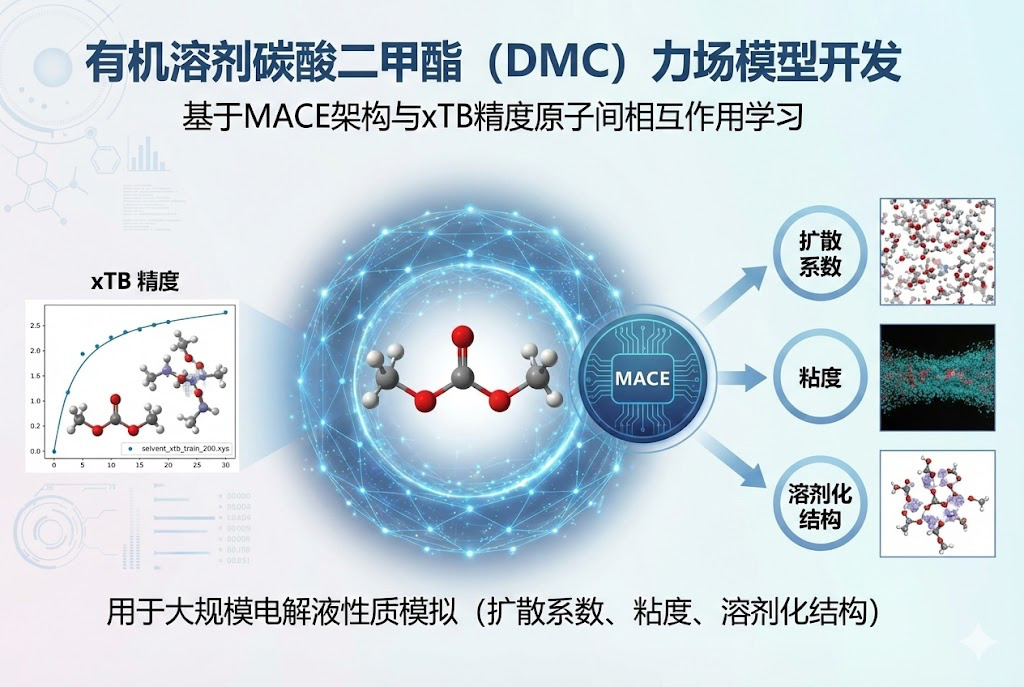
### 3.2 模型训练
  在SCNet的容器化终端，可看到MACE文件结构。运行scripts文件夹下的train.sh文件，进行单卡环境下的模型训练。
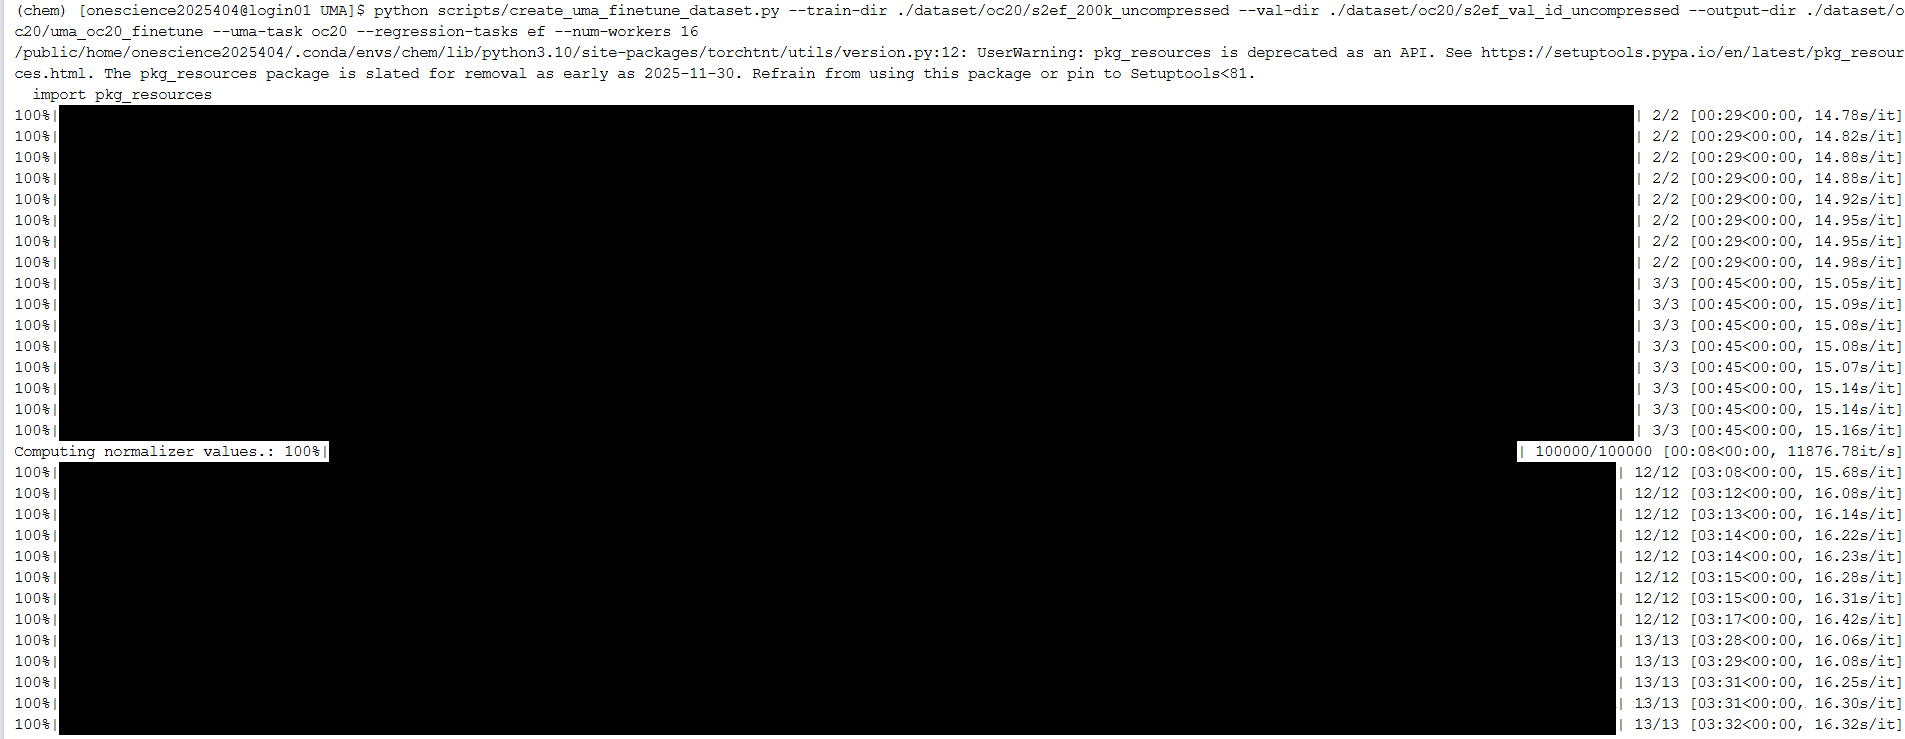
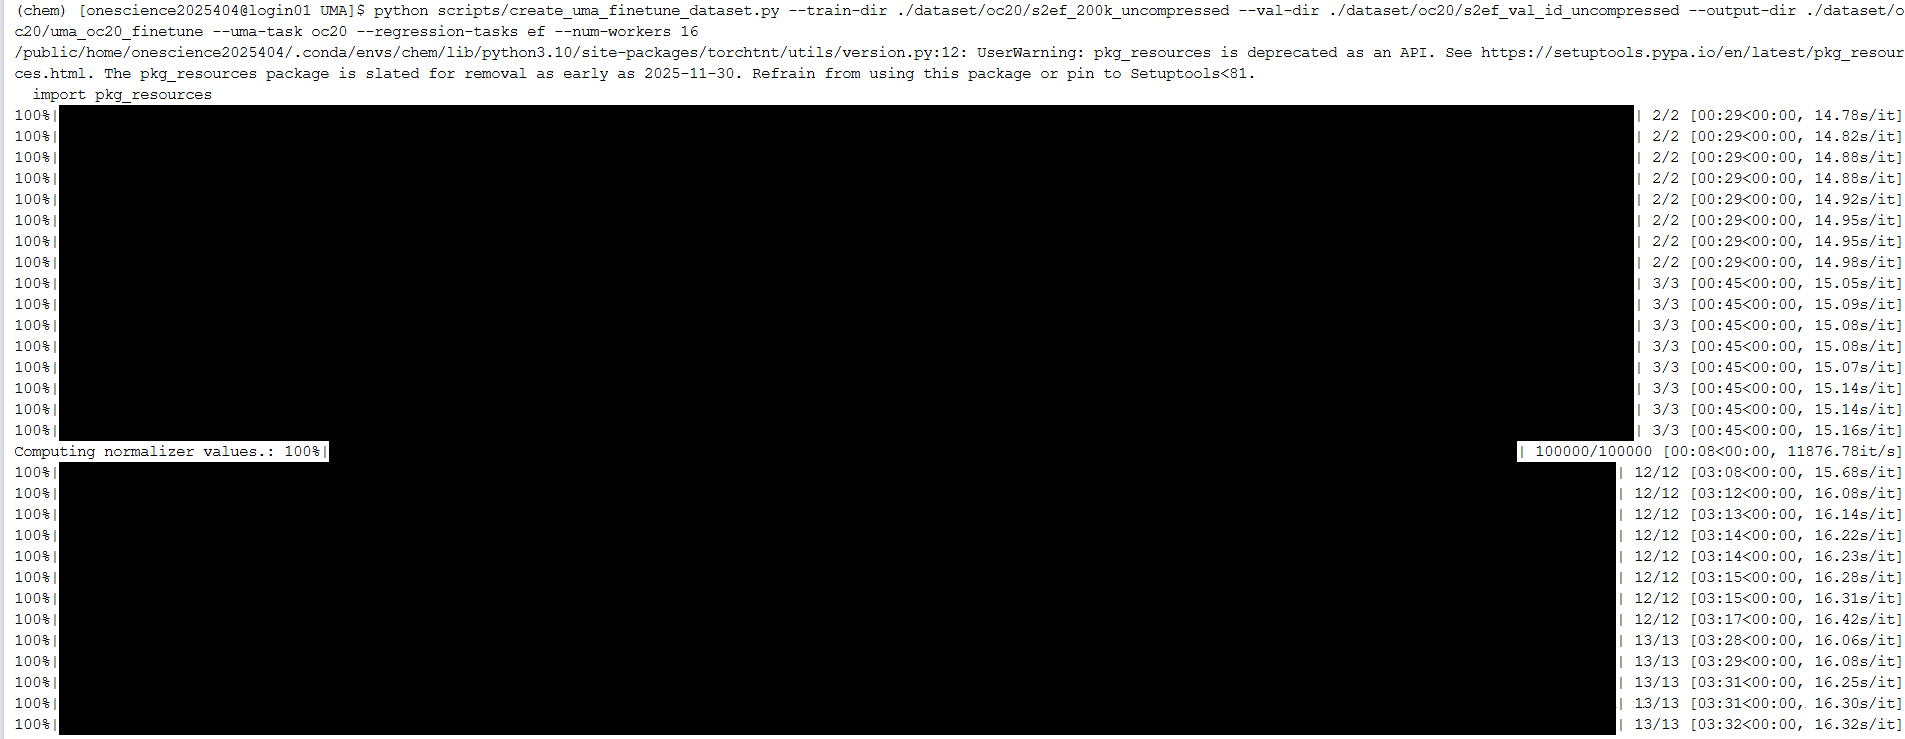
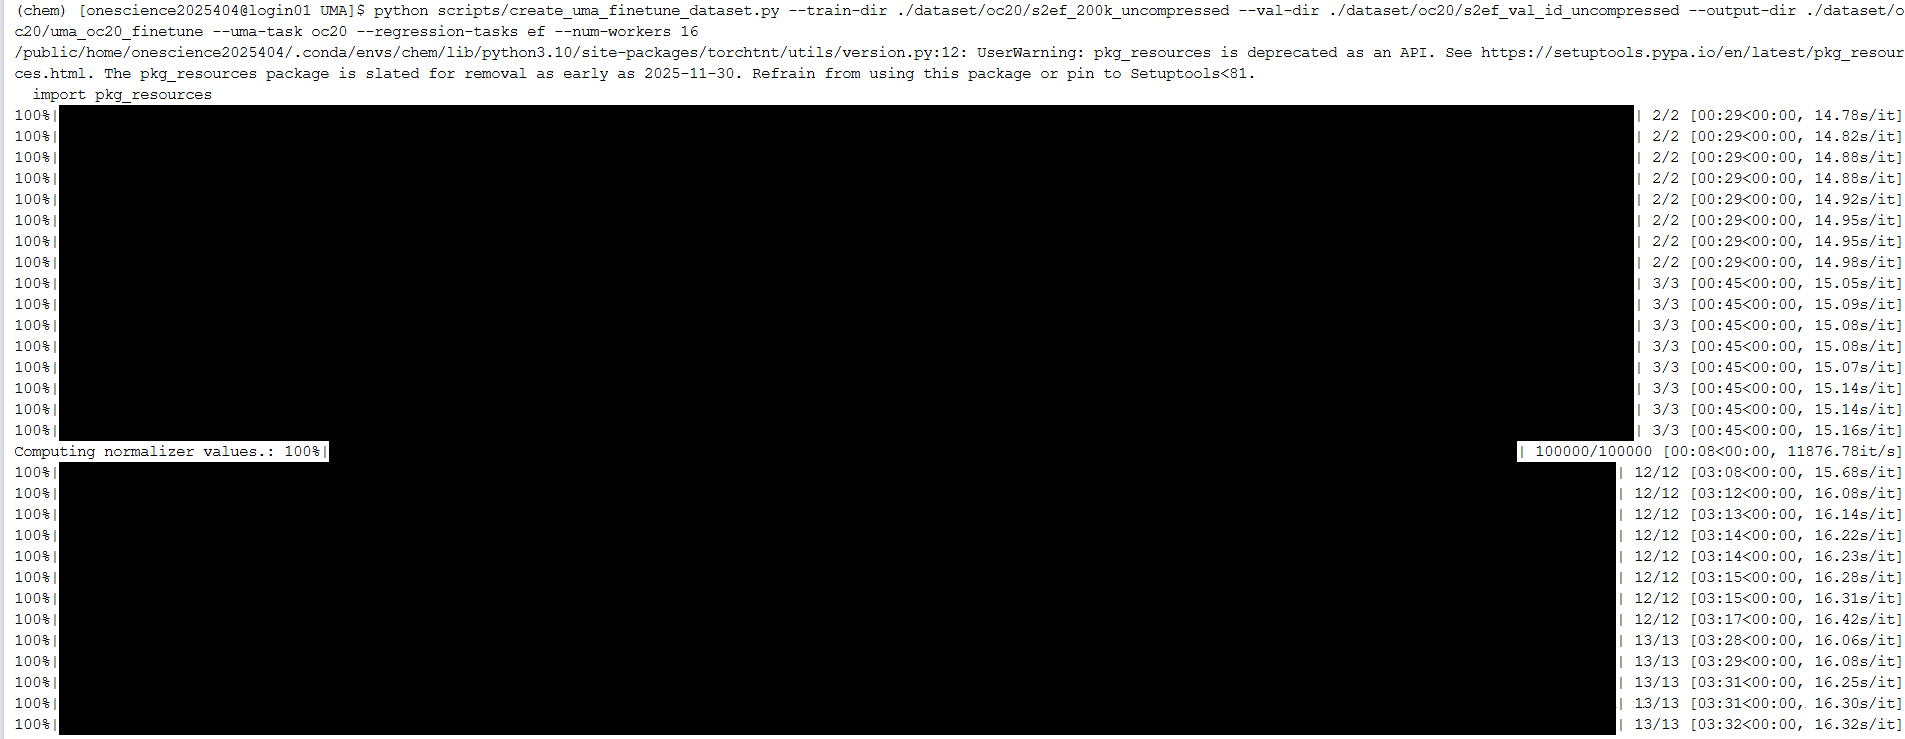
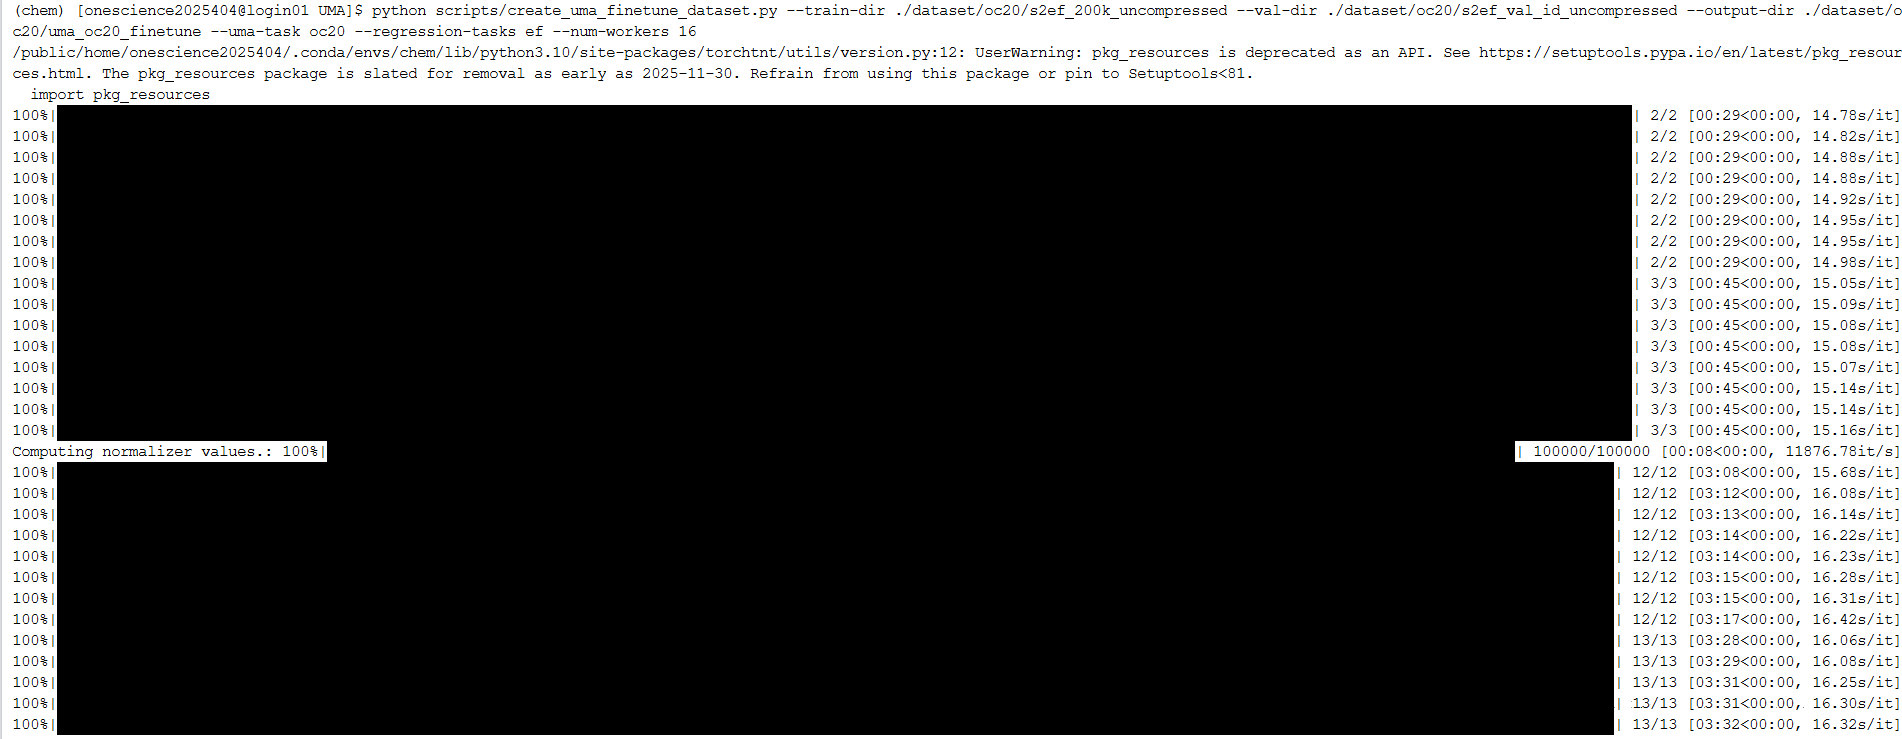
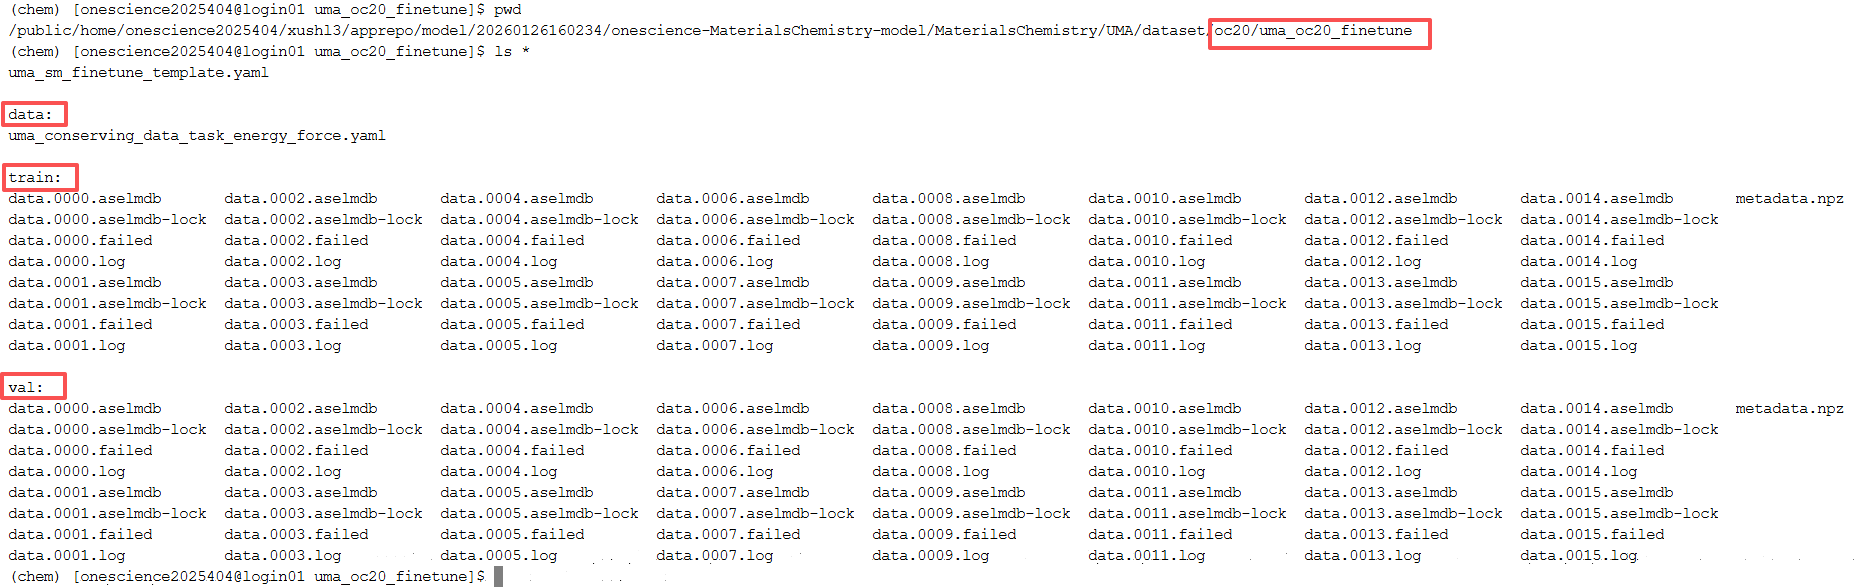

In [ ]:
#!/bin/bash
mkdir -p ./MACE_models
python train.py \
  --model="MACE" \
  --name="mace01" \
  --model_dir="./MACE_models" \
  --seed=123 \
  --device="cuda" \
  --r_max=4.0 \
  --batch_size=10 \
  --max_num_epochs=100 \
  --train_file="./data/solvent_xtb_train_200.xyz" \
  --test_file="./data/solvent_xtb_test.xyz" \
  --valid_fraction=0.10 \
  --energy_key="energy_xtb" \
  --forces_key="forces_xtb" \
  --E0s=average \
  --swa

MACE模型相关训练参数介绍：
name=“mace01” ： 实验名称，输出文件都会带有这个前缀信息；
model_dir="./MACE_models" ： 所有产出物的存放目录
r_max = 4.0 ：截断半径为4埃，适用于溶剂分子体系；
batch_size = 10 ： 每次训练迭代同时处理10个分子构型；
max_num_epochs = 100 ： 训练的总轮数；(100步仅用于代码调试，不能用于生产性任务)
train_file/test_file ： 数据集文件需放置在data目录下，可通过应用商城搜索“OneScience”，点击“数据、材料计算”进行下载获取。


### 3.3 结果可视化
  训练结束后，outputs/mace01下会存放对应的log信息、训练曲线图和最终模型。
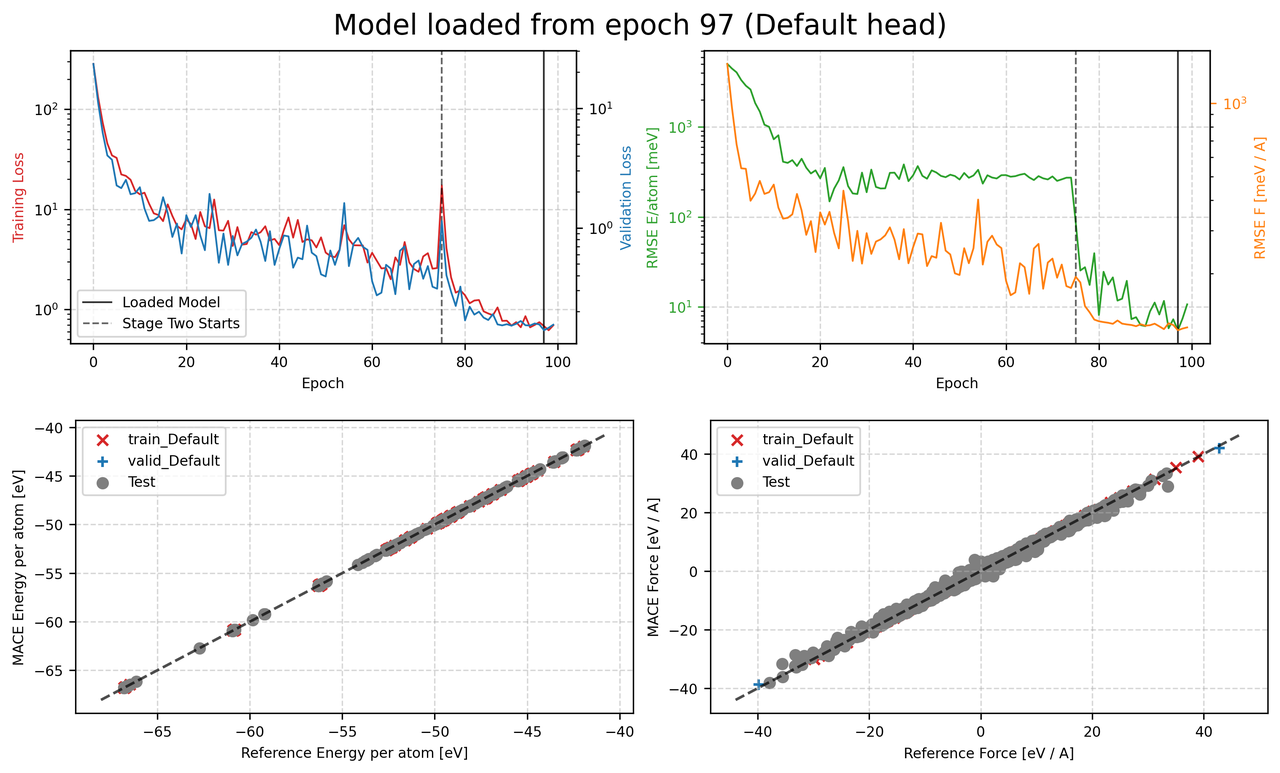
从上图中可以看出，模型Loss在100个Epoch内下降了2个数量级（228->1.6），RMSE_E/atom和RMSE_F分别从6.26eV和2.57eV/A下降到0.33 meV和0.12 eV/A，说明模型收敛情况良好，在当前设置下已完成最显著的学习阶段，后续可考虑增加数据集规模、调整训练轮数进行生产级模型训练，应用于大规模分子动力学模拟。